### Data Analysis for Open-Ended Pathology VQA

This code will perform the anaylysis for the data collected by the Pathologists

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

Reading the data

In [2]:
vqa_data = pd.read_csv('data/path_open_vqa.csv')
vqa_data = vqa_data.rename(columns={vqa_data.columns[2]: 'Image1_Path',
                                    vqa_data.columns[26]: 'Image2_Path',
                                    vqa_data.columns[27]: 'Image3_Path',
                                    vqa_data.columns[28]: 'Image4_Path',
                                    vqa_data.columns[29]: 'Image5_Path',
                                    'Image 1 Magnification ': 'Image1_Mag',
                                    'Image 2 Magnification ': 'Image2_Mag',
                                    'Image 3 Magnification ': 'Image3_Mag',
                                    'Image 4 Magnification ': 'Image4_Mag',
                                    'Image 5 Magnification ': 'Image5_Mag'})
vqa_data.head()

,Timestamp,Pathologist ID,Image1_Path,Organ,Categorization,Regional Anatomy,Open Ended - Question 1,Open Ended - Answer 1,Open Ended - Answer 2,Open Ended - Question 2,...,Open Ended - Wrong Answer 1,Open Ended - Wrong Answer 2,Image2_Mag,Image3_Mag,Image4_Mag,Image5_Mag,Image2_Path,Image3_Path,Image4_Path,Image5_Path
0,2/25/2025 13:41:20,CK,https://drive.google.com/open?id=1tgv50Q9W4Bm_...,Hematolymphoid - Lymph Nodes,Neoplasia (Malignant),Lymph node,What is the primary architectural pattern obse...,Nodular pattern,Germinal centers are absent,What is a common component of lymph node archi...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2/25/2025 13:46:25,CK,https://drive.google.com/open?id=1igYpj4RL0XKx...,Hematolymphoid - Lymph Nodes,Neoplasia (Malignant),Lymph node,What is the predominant cell type seen here?,The main cell type observed here is a lymphocy...,These would best be characterized as small lym...,What is the best description for the cell size...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2/25/2025 13:51:37,CK,https://drive.google.com/open?id=1DKNZJQJ17SkX...,Hematolymphoid - Lymph Nodes,Neoplasia (Malignant),Lymph node,"In this mantle cell lymphoma, what is the best...",The nuclei of the abnormal lymphocytes are mos...,This should be considered a highly cellular ti...,What is the best description for the density a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2/26/2025 11:30:23,CK,https://drive.google.com/open?id=1jUe0z6wlZ0s9...,Gastrointestinal - Small Intenstine,Infection (Benign),Intestinal villous mucosa,"In a child with poor weight gain, what are the...",Features that argue against celiac disease in ...,Granulomas here are often the consequence of u...,What does the granuloma in the lamina propria ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2/26/2025 11:42:26,CK,https://drive.google.com/open?id=1VNr78I5w671g...,Gastrointestinal - Dudenum,Infection (Benign),Intestinal villous mucosa,What are the main histologic features of a non...,Non-necrotizing granulomas are characterized b...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Total Cases/Images

In [3]:
print("Total Cases:", len(vqa_data))
print("Total Images 1:", sum(~vqa_data['Image1_Path'].isnull()))
print("Total Images 2:", sum(~vqa_data['Image2_Path'].isnull()))
print("Total Images 3:", sum(~vqa_data['Image3_Path'].isnull()))
print("Total Images 4:", sum(~vqa_data['Image4_Path'].isnull()))
print("Total Images 5:", sum(~vqa_data['Image5_Path'].isnull()))

Total Cases: 157
Total Images 1: 157
Total Images 2: 37
Total Images 3: 37
Total Images 4: 0
Total Images 5: 0


#### Pathologist  Cases Breakdown

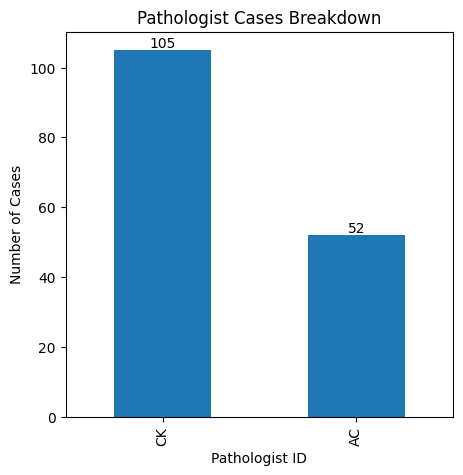

In [4]:
ax = vqa_data['Pathologist ID'].value_counts().plot(kind='bar', figsize=(5, 5), title='Pathologist Cases Breakdown', xlabel='Pathologist ID', ylabel='Number of Cases', label='Pathologist ID')
ax.bar_label(ax.containers[0])
plt.show()

#### Image Magnification Breakdown

It was reported that the Pathologist CK didn't include the magnification of the eyepience lens (10x) while reporting the resolution of the images where pathologist AC included all those. So, to make this data consistent, resolutions collected by CK are being multiplied with 10 to ensure that resolution reflects the objective magnification of the microscope multiplied by the eyepiece lens magnification

Image Magnifications Reported by AC

In [5]:
vqa_data[vqa_data['Pathologist ID'] == 'AC'][['Image1_Mag', 'Image2_Mag', 'Image3_Mag']].apply(pd.Series.value_counts)

,Image1_Mag,Image2_Mag,Image3_Mag
100x,23,NaN,NaN
200x,19,NaN,NaN
20x,2,NaN,NaN
400x,4,NaN,NaN
40x,4,NaN,NaN


Image Magnifications Reported by CK

In [6]:
vqa_data[vqa_data['Pathologist ID'] == 'CK'][['Image1_Mag', 'Image2_Mag', 'Image3_Mag']].apply(pd.Series.value_counts)

,Image1_Mag,Image2_Mag,Image3_Mag
10X,1.0,NaN,NaN
10x,31.0,6.0,10.0
20x,33.0,11.0,10.0
2x,13.0,7.0,2.0
40x,8.0,3.0,2.0
4X,NaN,NaN,1.0
4x,16.0,10.0,8.0
5X,1.0,NaN,NaN
5x,2.0,NaN,4.0


This shows that CK did not incorporate the magnification of eyepiece lens (10x) when reporting the overall image resolution. So multiplying all the magnifications reported by CK by 10 will make our data consistent

In [7]:
def convert_mag(mag):
    path_id = mag.iloc[0]
    image_mag = mag.iloc[1]
    if pd.isnull(image_mag):
        return image_mag
    
    image_mag = image_mag.lower().strip()
    if path_id == 'CK':    
        if 'x' in image_mag:
            return str(int(image_mag.split('x')[0]) * 10) + 'x'
    return image_mag


In [8]:
vqa_data['Image1_Mag'] = vqa_data[['Pathologist ID', 'Image1_Mag']].apply(convert_mag, axis=1)
vqa_data['Image2_Mag'] = vqa_data[['Pathologist ID', 'Image2_Mag']].apply(convert_mag, axis=1)
vqa_data['Image3_Mag'] = vqa_data[['Pathologist ID', 'Image3_Mag']].apply(convert_mag, axis=1)

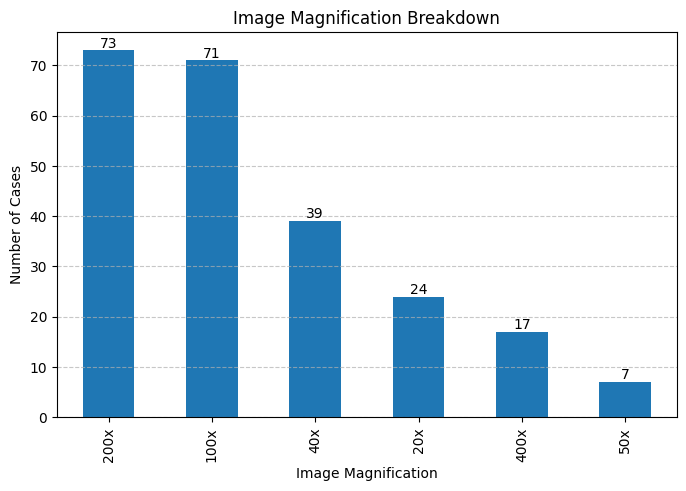

In [9]:
image1_mag_counts = vqa_data['Image1_Mag'].value_counts()
image2_mag_counts = vqa_data['Image2_Mag'].value_counts()
image3_mag_counts = vqa_data['Image3_Mag'].value_counts()

image_mag_counts = image1_mag_counts.add(image2_mag_counts, fill_value=0).add(image3_mag_counts, fill_value=0).sort_values(ascending=False)

ax = image_mag_counts.plot(kind='bar', figsize=(8, 5), title='Image Magnification Breakdown', xlabel='Image Magnification', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Organ Breakdown

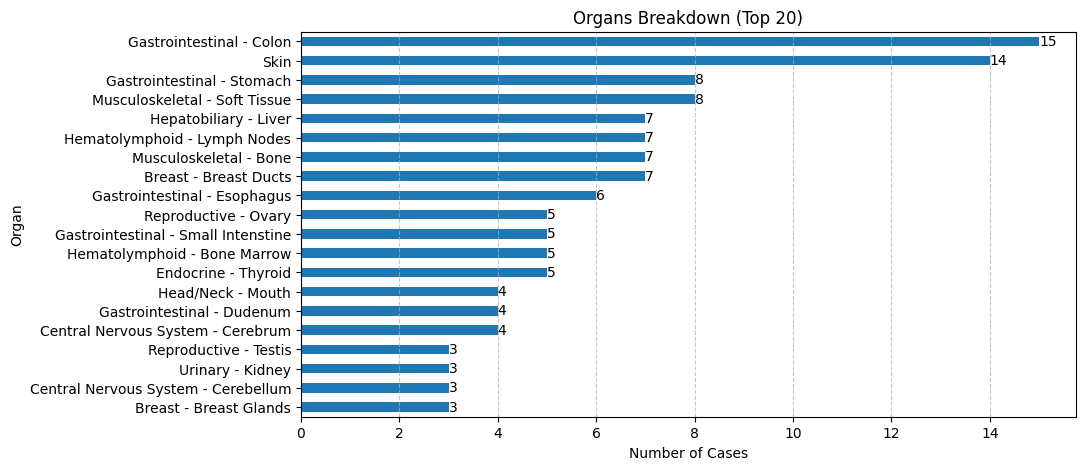

In [10]:
ax = vqa_data['Organ'].value_counts().head(20).plot(kind='barh', figsize=(10, 5), title='Organs Breakdown (Top 20)', xlabel='Number of Cases', ylabel='Organ')
ax.bar_label(ax.containers[0])
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.invert_yaxis()
plt.show()

#### Categorization Breakdown

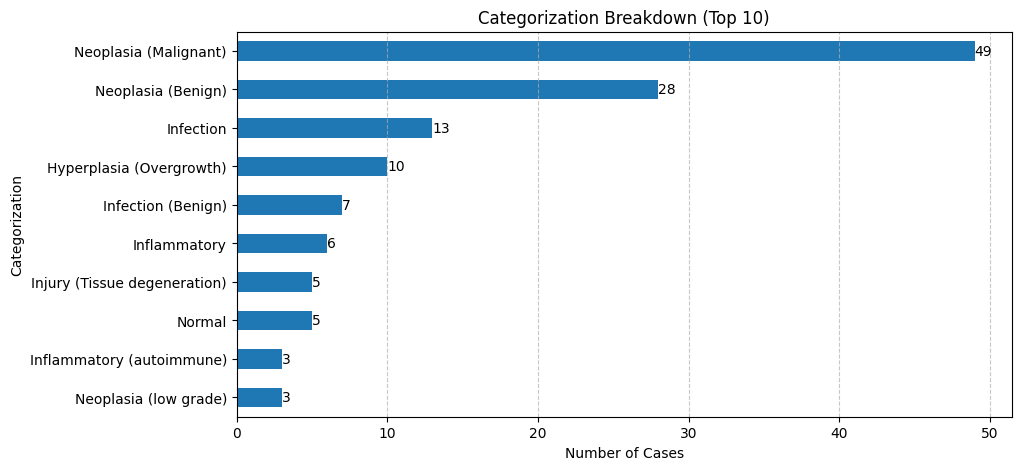

In [11]:
ax = vqa_data['Categorization'].value_counts().head(10).plot(kind='barh', figsize=(10, 5), title='Categorization Breakdown (Top 10)', xlabel='Number of Cases', ylabel='Categorization')
ax.bar_label(ax.containers[0])
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.invert_yaxis()
plt.show()

#### Regional Anatomy Breakdown

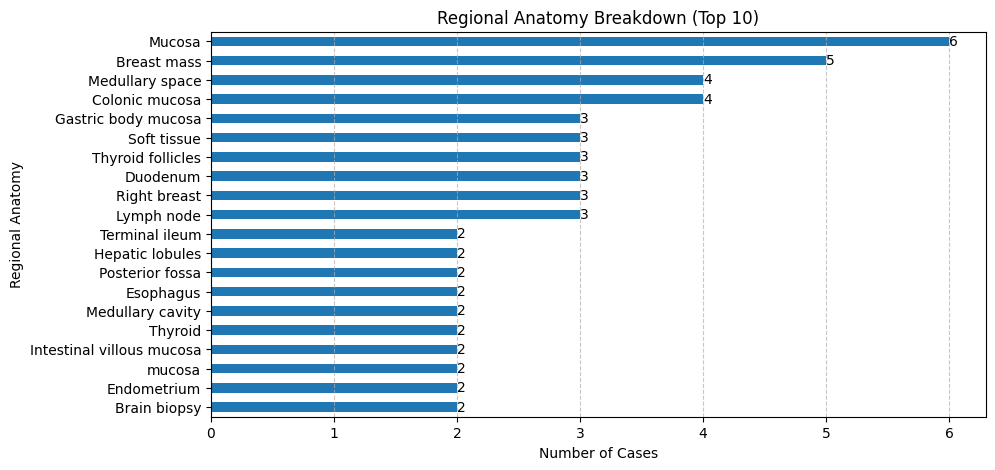

In [12]:
ax = vqa_data['Regional Anatomy'].value_counts().head(20).plot(kind='barh', figsize=(10, 5), title='Regional Anatomy Breakdown (Top 10)', xlabel='Number of Cases', ylabel='Regional Anatomy')
ax.bar_label(ax.containers[0])
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.invert_yaxis()
plt.show()

### Differentiating cases with multiple images versus the ones having a single image

In [20]:
vqa_data_sngl_img = vqa_data[vqa_data['Image1_Path'].notnull() & vqa_data['Image2_Path'].isnull() & vqa_data['Image3_Path'].isnull()]
vqa_data_mult_img = vqa_data[vqa_data['Image1_Path'].notnull() & (vqa_data['Image2_Path'].notnull() | vqa_data['Image3_Path'].notnull())]
print("Cases with Single Image:", len(vqa_data_sngl_img))
print("Cases with Multiple Images:", len(vqa_data_mult_img))

Cases with Single Image: 120
Cases with Multiple Images: 37


#### Open-Ended Questions/Answers with cases having Single Images

In [ ]:
open_ended_1 = vqa_data_sngl_img[vqa_data_sngl_img['Open Ended - Question 1'].notnull() & vqa_data_sngl_img['Open Ended - Answer 1'].notnull()]
open_ended_1_with_wrong = vqa_data_sngl_img[vqa_data_sngl_img['Open Ended - Question 1'].notnull() & vqa_data_sngl_img['Open Ended - Answer 1'].notnull() & vqa_data_sngl_img['Open Ended - Wrong Answer 1'].notnull()]
open_ended_1_without_wrong = vqa_data_sngl_img[vqa_data_sngl_img['Open Ended - Question 1'].notnull() & vqa_data_sngl_img['Open Ended - Answer 1'].notnull() & vqa_data_sngl_img['Open Ended - Wrong Answer 1'].isnull()]

open_ended_2 = vqa_data_sngl_img[vqa_data_sngl_img['Open Ended - Question 2'].notnull() & vqa_data_sngl_img['Open Ended - Answer 2'].notnull()]
open_ended_2_with_wrong = vqa_data_sngl_img[vqa_data_sngl_img['Open Ended - Question 2'].notnull() & vqa_data_sngl_img['Open Ended - Answer 2'].notnull() & vqa_data_sngl_img['Open Ended - Wrong Answer 2'].notnull()]
open_ended_2_without_wrong = vqa_data_sngl_img[vqa_data_sngl_img['Open Ended - Question 2'].notnull() & vqa_data_sngl_img['Open Ended - Answer 2'].notnull() & vqa_data_sngl_img['Open Ended - Wrong Answer 2'].isnull()]

In [24]:
open_ended_sngl = pd.concat([open_ended_1, open_ended_2])
open_ended_with_wrong_sngl = pd.concat([open_ended_1_with_wrong, open_ended_2_with_wrong])
open_ended_without_wrong_sngl = pd.concat([open_ended_1_without_wrong, open_ended_2_without_wrong])

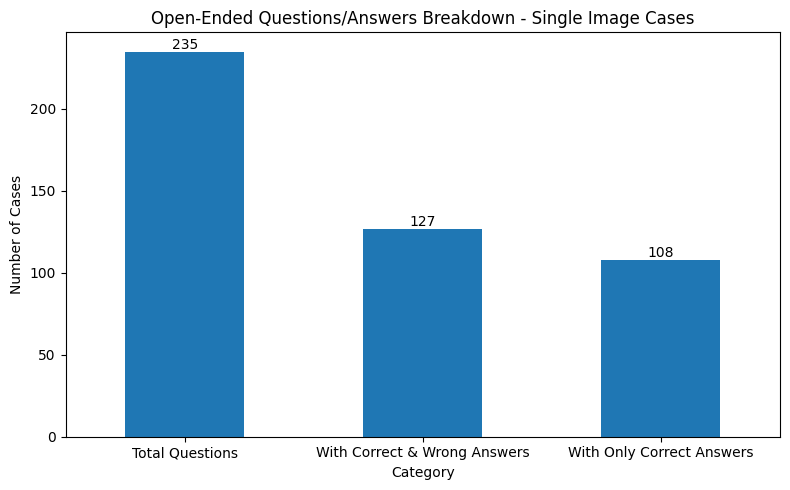

In [36]:
ax = pd.Series({
    'Total Questions': len(open_ended_sngl),
    'With Correct & Wrong Answers': len(open_ended_with_wrong_sngl),
    'With Only Correct Answers': len(open_ended_without_wrong_sngl)
}).plot(kind='bar', figsize=(8, 5), title='Open-Ended Questions/Answers Breakdown - Single Image Cases', xlabel='Category', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Open-Ended Questions/Answers with cases having Multiple Images

In [37]:
open_ended_1 = vqa_data_mult_img[vqa_data_mult_img['Open Ended - Question 1'].notnull() & vqa_data_mult_img['Open Ended - Answer 1'].notnull()]
open_ended_1_with_wrong = vqa_data_mult_img[vqa_data_mult_img['Open Ended - Question 1'].notnull() & vqa_data_mult_img['Open Ended - Answer 1'].notnull() & vqa_data_mult_img['Open Ended - Wrong Answer 1'].notnull()]
open_ended_1_without_wrong = vqa_data_mult_img[vqa_data_mult_img['Open Ended - Question 1'].notnull() & vqa_data_mult_img['Open Ended - Answer 1'].notnull() & vqa_data_mult_img['Open Ended - Wrong Answer 1'].isnull()]

open_ended_2 = vqa_data_mult_img[vqa_data_mult_img['Open Ended - Question 2'].notnull() & vqa_data_mult_img['Open Ended - Answer 2'].notnull()]
open_ended_2_with_wrong = vqa_data_mult_img[vqa_data_mult_img['Open Ended - Question 2'].notnull() & vqa_data_mult_img['Open Ended - Answer 2'].notnull() & vqa_data_mult_img['Open Ended - Wrong Answer 2'].notnull()]
open_ended_2_without_wrong = vqa_data_mult_img[vqa_data_mult_img['Open Ended - Question 2'].notnull() & vqa_data_mult_img['Open Ended - Answer 2'].notnull() & vqa_data_mult_img['Open Ended - Wrong Answer 2'].isnull()]

In [38]:
open_ended_mult = pd.concat([open_ended_1, open_ended_2])
open_ended_with_wrong_mult = pd.concat([open_ended_1_with_wrong, open_ended_2_with_wrong])
open_ended_without_wrong_mult = pd.concat([open_ended_1_without_wrong, open_ended_2_without_wrong])

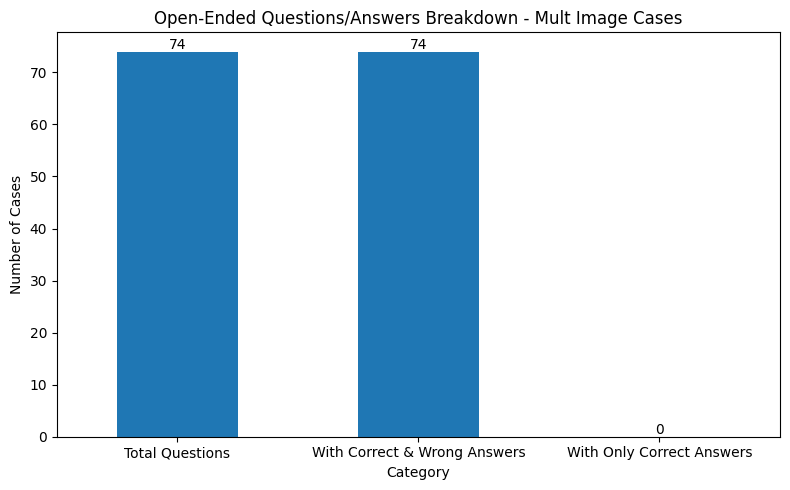

In [39]:
ax = pd.Series({
    'Total Questions': len(open_ended_mult),
    'With Correct & Wrong Answers': len(open_ended_with_wrong_mult),
    'With Only Correct Answers': len(open_ended_without_wrong_mult)
}).plot(kind='bar', figsize=(8, 5), title='Open-Ended Questions/Answers Breakdown - Mult Image Cases', xlabel='Category', ylabel='Number of Cases')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Extracting Word Distribution

In [44]:
open_ended = pd.concat([open_ended_sngl, open_ended_mult])
open_ended_with_wrong = pd.concat([open_ended_with_wrong_sngl, open_ended_with_wrong_mult])
open_ended_without_wrong = pd.concat([open_ended_without_wrong_sngl, open_ended_without_wrong_mult])

In [77]:
open_ended_questions = list(open_ended['Open Ended - Question 1'].dropna().unique()) + list(open_ended['Open Ended - Question 2'].dropna().unique())
open_ended_correct_answers = list(open_ended['Open Ended - Answer 1'].dropna().unique()) + list(open_ended['Open Ended - Answer 2'].dropna().unique())
open_ended_wrong_answers = list(open_ended['Open Ended - Wrong Answer 1'].dropna().unique()) + list(open_ended['Open Ended - Wrong Answer 2'].dropna().unique())

valid_open_ended_questions = [sample for sample in open_ended_questions if len(sample.split()) >= 5]
valid_open_ended_correct_answers = [sample for sample in open_ended_correct_answers if len(sample.split()) >= 5]
valid_open_ended_wrong_answers = [sample for sample in open_ended_wrong_answers if len(sample.split()) >= 5]

print(f'Number of Open-Ended Questions (Words >= 5): {len(valid_open_ended_questions)}/{len(open_ended_questions)}')
print(f'Number of Open-Ended Correct Answers (Words >= 5): {len(valid_open_ended_correct_answers)}/{len(open_ended_correct_answers)}')
print(f'Number of Open-Ended Wrong Answers (Words >= 5): {len(valid_open_ended_wrong_answers)}/{len(open_ended_wrong_answers)}')

open_ended_questions_first_word = [sample.split()[0].lower() for sample in open_ended_questions]
open_ended_first_word_counts = Counter(open_ended_questions_first_word)
print(f"First Word in Open-Ended Questions: ", open_ended_first_word_counts)

Number of Open-Ended Questions (Words >= 5): 306/306
Number of Open-Ended Correct Answers (Words >= 5): 306/309
Number of Open-Ended Wrong Answers (Words >= 5): 201/201
First Word in Open-Ended Questions:  Counter({'what': 198, 'how': 29, 'considering': 23, 'in': 17, 'assuming': 10, 'the': 5, 'if': 4, 'this': 4, 'based': 4, 'given': 3, 'is': 2, 'describe': 1, 'why': 1, 'where': 1, 'does': 1, 'which': 1, 'for': 1, 'under': 1})


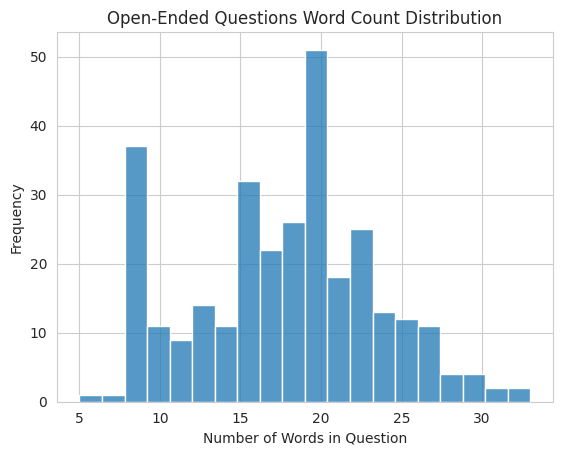

In [46]:
open_ended_questions_words_distrib = [len(sample.split()) for sample in open_ended_questions]
sns.set_style("whitegrid")
sns.histplot(open_ended_questions_words_distrib, bins=20)
plt.title(f'Open-Ended Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

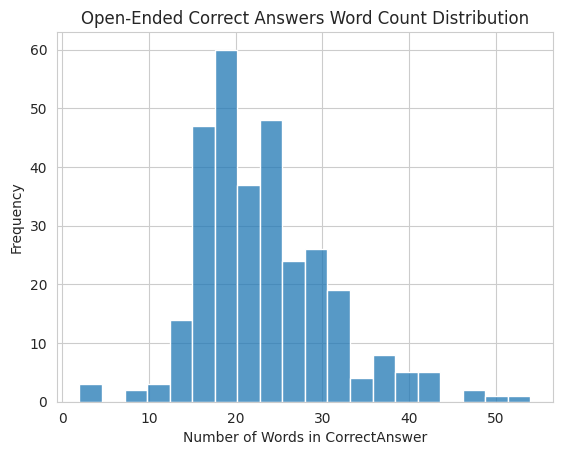

In [ ]:
open_ended_correct_answers_words_distrib = [len(sample.split()) for sample in open_ended_correct_answers]
sns.set_style("whitegrid")
sns.histplot(open_ended_correct_answers_words_distrib, bins=20)
plt.title(f'Open-Ended Correct Answers Word Count Distribution')
plt.xlabel('Number of Words in Correct Answer')
plt.ylabel('Frequency')
plt.show()

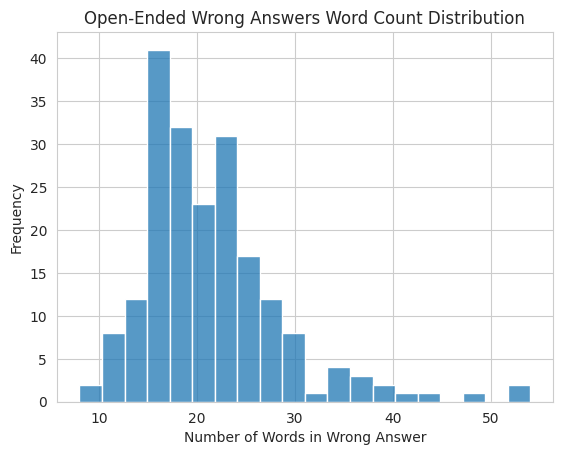

In [48]:
open_ended_wrong_answers_words_distrib = [len(sample.split()) for sample in open_ended_wrong_answers]
sns.set_style("whitegrid")
sns.histplot(open_ended_wrong_answers_words_distrib, bins=20)
plt.title(f'Open-Ended Wrong Answers Word Count Distribution')
plt.xlabel('Number of Words in Wrong Answer')
plt.ylabel('Frequency')
plt.show()

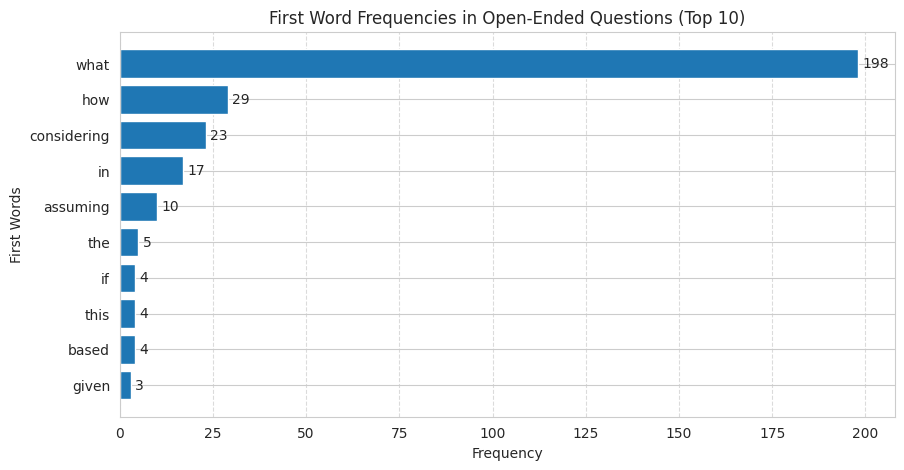

In [79]:
labels = [item[0] for item in open_ended_first_word_counts.most_common(10)]
values = [item[1] for item in open_ended_first_word_counts.most_common(10)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values)
ax.bar_label(bars, padding=3)
ax.set_xlabel('Frequency')
ax.set_ylabel('First Words')
ax.set_title('First Word Frequencies in Open-Ended Questions (Top 10)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.invert_yaxis()
plt.show()

### Multiple Choice Questions/Answers

In [68]:
print("Total MCQ Questions/Answers: ", len(vqa_data[(~vqa_data['MCQ - Question'].isnull()) &
                                        (~vqa_data['MCQ - Option 1'].isnull()) &
                                        (~vqa_data['MCQ - Option 2'].isnull()) &
                                        (~vqa_data['MCQ - Option 3'].isnull()) &
                                        (~vqa_data['MCQ - Option 4'].isnull()) &
                                        (~vqa_data['MCQ - Option 5'].isnull()) &
                                        (~vqa_data['MCQ - Answer'].isnull())]))

Total MCQ Questions/Answers:  157


Extracting Words Distribution

In [80]:
mcq_questions = list(vqa_data['MCQ - Question'].dropna().unique())
mcq_options_1 = list(vqa_data['MCQ - Option 1'].dropna().unique())
mcq_options_2 = list(vqa_data['MCQ - Option 2'].dropna().unique())
mcq_options_3 = list(vqa_data['MCQ - Option 3'].dropna().unique())
mcq_options_4 = list(vqa_data['MCQ - Option 4'].dropna().unique())
mcq_options_5 = list(vqa_data['MCQ - Option 5'].dropna().unique())

valid_mcq_questions = [sample for sample in mcq_questions if len(sample.split()) >= 5]
valid_mcq_options_1 = [sample for sample in mcq_options_1 if len(sample.split()) >= 5]
valid_mcq_options_2 = [sample for sample in mcq_options_2 if len(sample.split()) >= 5]
valid_mcq_options_3 = [sample for sample in mcq_options_3 if len(sample.split()) >= 5]
valid_mcq_options_4 = [sample for sample in mcq_options_4 if len(sample.split()) >= 5]
valid_mcq_options_5 = [sample for sample in mcq_options_5 if len(sample.split()) >= 5]

print(f'Number of MCQ Questions (Words >= 5): {len(valid_mcq_questions)}/{len(mcq_questions)}')
print(f'Number of MCQ Options 1 (Words >= 5): {len(valid_mcq_options_1)}/{len(mcq_options_1)}')
print(f'Number of MCQ Options 2 (Words >= 5): {len(valid_mcq_options_2)}/{len(mcq_options_2)}')
print(f'Number of MCQ Options 3 (Words >= 5): {len(valid_mcq_options_3)}/{len(mcq_options_3)}')
print(f'Number of MCQ Options 4 (Words >= 5): {len(valid_mcq_options_4)}/{len(mcq_options_4)}')
print(f'Number of MCQ Options 5 (Words >= 5): {len(valid_mcq_options_5)}/{len(mcq_options_5)}')

mcq_questions_first_word = [sample.split()[0].lower() for sample in mcq_questions]
mcq_questions_first_word_counts = Counter(mcq_questions_first_word)
print(f"First Word in MCQ Questions: ", mcq_questions_first_word_counts)

Number of MCQ Questions (Words >= 5): 155/155
Number of MCQ Options 1 (Words >= 5): 102/155
Number of MCQ Options 2 (Words >= 5): 101/154
Number of MCQ Options 3 (Words >= 5): 99/156
Number of MCQ Options 4 (Words >= 5): 104/156
Number of MCQ Options 5 (Words >= 5): 100/154
First Word in MCQ Questions:  Counter({'what': 81, 'considering': 30, 'in': 8, 'assuming': 6, 'the': 5, 'which': 4, 'given': 4, 'if': 3, 'for': 2, 'based': 2, 'is': 2, 'how': 2, 'lymphocytes': 1, 'hyperkeratosis,': 1, 'all': 1, 'finding': 1, 'this': 1, 'a': 1})


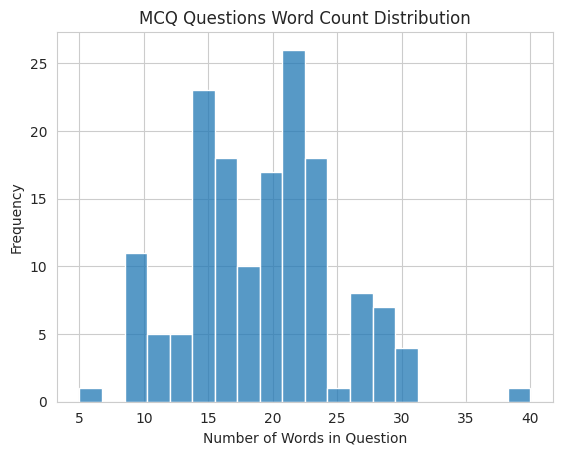

In [71]:
mcq_questions_words_distrib = [len(sample.split()) for sample in mcq_questions]
sns.set_style("whitegrid")
sns.histplot(mcq_questions_words_distrib, bins=20)
plt.title(f'MCQ Questions Word Count Distribution')
plt.xlabel('Number of Words in Question')
plt.ylabel('Frequency')
plt.show()

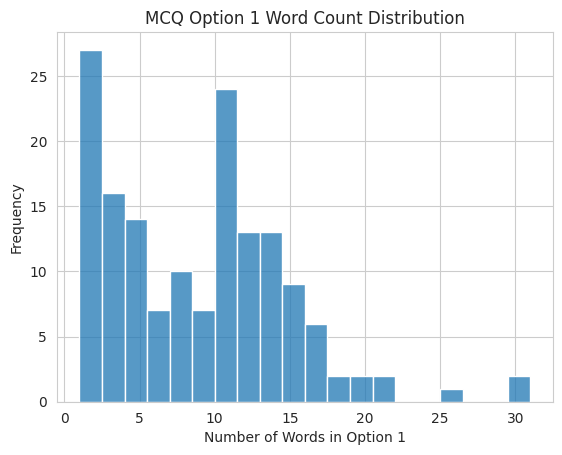

In [72]:
mcq_option_1_words_distrib = [len(sample.split()) for sample in mcq_options_1]
sns.set_style("whitegrid")
sns.histplot(mcq_option_1_words_distrib, bins=20)
plt.title(f'MCQ Option 1 Word Count Distribution')
plt.xlabel('Number of Words in Option 1')
plt.ylabel('Frequency')
plt.show()

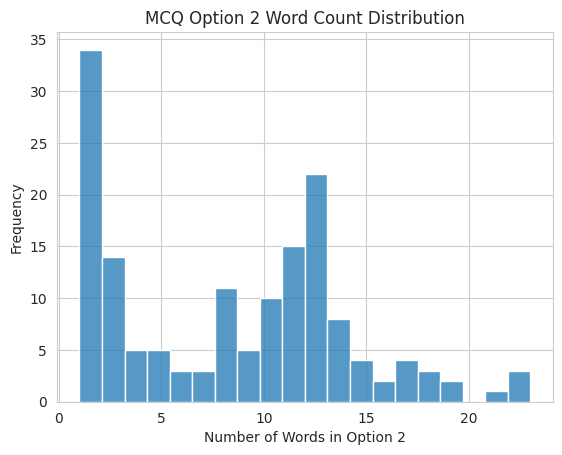

In [73]:
mcq_option_2_words_distrib = [len(sample.split()) for sample in mcq_options_2]
sns.set_style("whitegrid")
sns.histplot(mcq_option_2_words_distrib, bins=20)
plt.title(f'MCQ Option 2 Word Count Distribution')
plt.xlabel('Number of Words in Option 2')
plt.ylabel('Frequency')
plt.show()

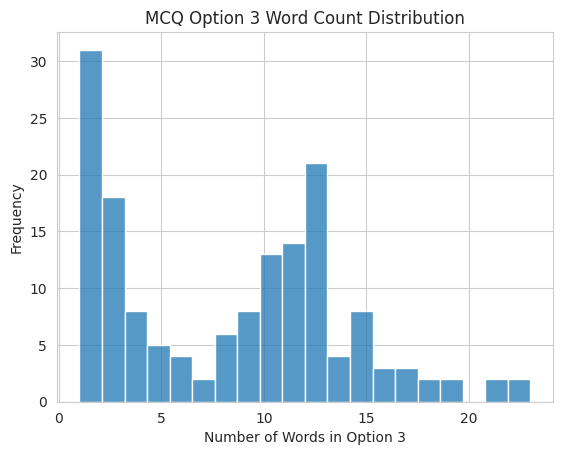

In [74]:
mcq_option_3_words_distrib = [len(sample.split()) for sample in mcq_options_3]
sns.set_style("whitegrid")
sns.histplot(mcq_option_3_words_distrib, bins=20)
plt.title(f'MCQ Option 3 Word Count Distribution')
plt.xlabel('Number of Words in Option 3')
plt.ylabel('Frequency')
plt.show()

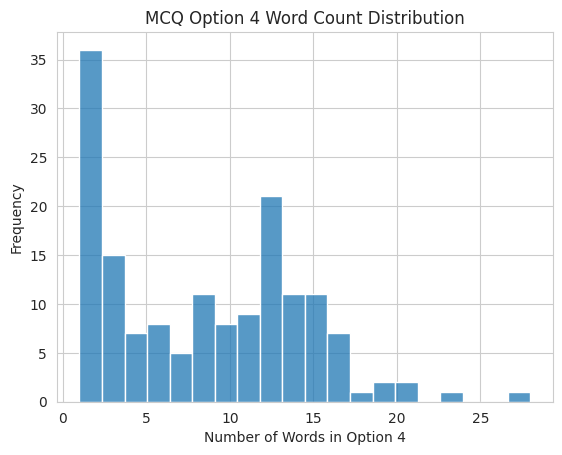

In [75]:
mcq_option_4_words_distrib = [len(sample.split()) for sample in mcq_options_4]
sns.set_style("whitegrid")
sns.histplot(mcq_option_4_words_distrib, bins=20)
plt.title(f'MCQ Option 4 Word Count Distribution')
plt.xlabel('Number of Words in Option 4')
plt.ylabel('Frequency')
plt.show()

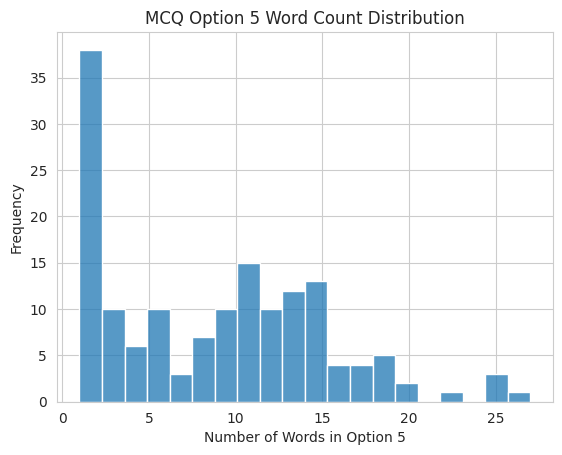

In [76]:
mcq_option_5_words_distrib = [len(sample.split()) for sample in mcq_options_5]
sns.set_style("whitegrid")
sns.histplot(mcq_option_5_words_distrib, bins=20)
plt.title(f'MCQ Option 5 Word Count Distribution')
plt.xlabel('Number of Words in Option 5')
plt.ylabel('Frequency')
plt.show()

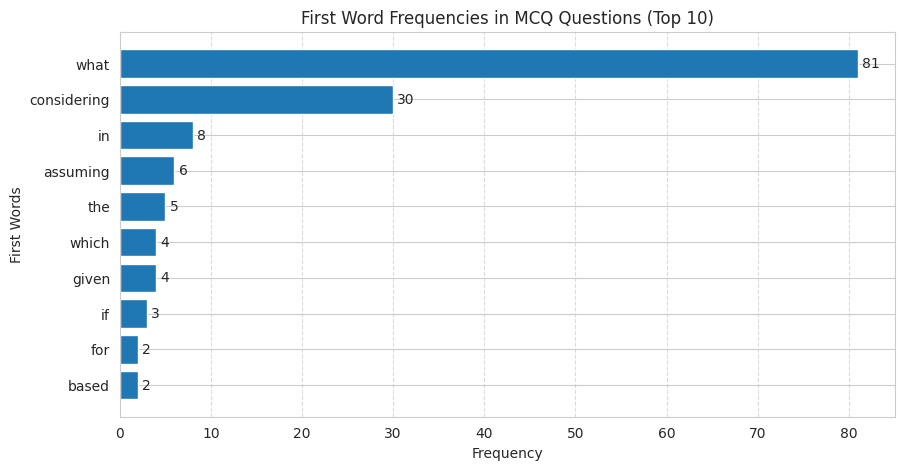

In [ ]:
labels = [item[0] for item in mcq_questions_first_word_counts.most_common(10)]
values = [item[1] for item in mcq_questions_first_word_counts.most_common(10)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values)
ax.bar_label(bars, padding=3)
ax.set_xlabel('Frequency')
ax.set_ylabel('First Words')
ax.set_title('First Word Frequencies in MCQ Questions (Top 10)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.invert_yaxis()
plt.show()

#### Close-Ended Questions/Answers

In [82]:
print("Total Close-Ended Questions/Answers: ", len(vqa_data[(~vqa_data['Close-Ended Question 1'].isnull()) &
                                                    (~vqa_data['Close-Ended Answer 1'].isnull())]))

Total Close-Ended Questions/Answers:  157


In [83]:
close_ended_questions = list(vqa_data['Close-Ended Question 1'].dropna().unique())

valid_close_ended_questions = [sample for sample in close_ended_questions if len(sample.split()) >= 5]

print(f'Number of Close-Ended Questions (Words >= 5): {len(valid_close_ended_questions)}/{len(close_ended_questions)}')

close_ended_questions_first_word = [sample.split()[0].lower() for sample in valid_close_ended_questions]
close_ended_first_word_counts = Counter(close_ended_questions_first_word)
print(f"First Word in Close-Ended Questions: ", close_ended_first_word_counts)

Number of Close-Ended Questions (Words >= 5): 152/154
First Word in Close-Ended Questions:  Counter({'is': 60, 'does': 39, 'would': 15, 'are': 13, 'could': 5, 'do': 4, 'can': 3, 'the': 2, 'this': 2, 'considering': 2, 'increased': 1, 'one': 1, 'in': 1, 'if': 1, 'should': 1, 'assuming': 1, 'i': 1})


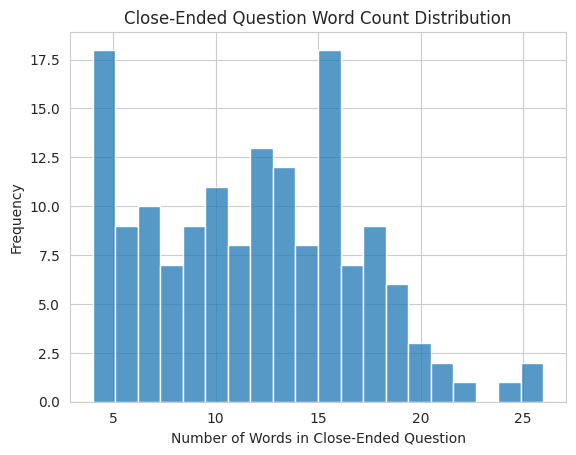

In [84]:
close_ended_questions_words_distrib = [len(sample.split()) for sample in close_ended_questions]
sns.set_style("whitegrid")
sns.histplot(close_ended_questions_words_distrib, bins=20)
plt.title(f'Close-Ended Question Word Count Distribution')
plt.xlabel('Number of Words in Close-Ended Question')
plt.ylabel('Frequency')
plt.show()

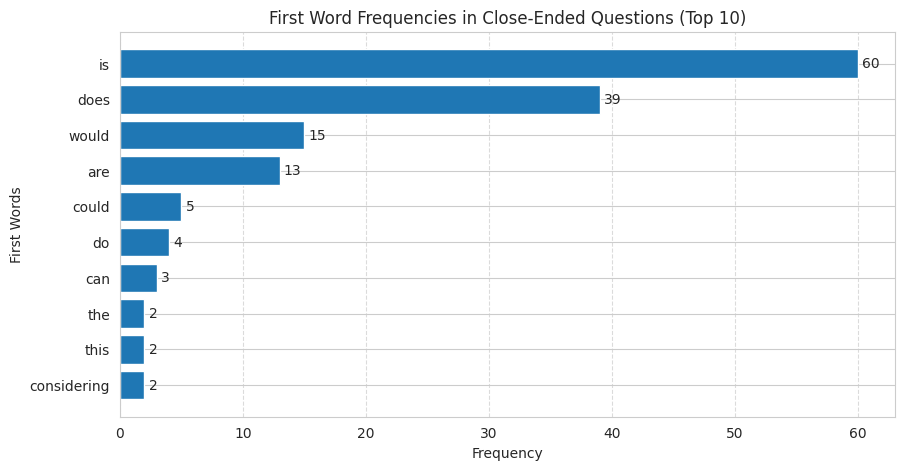

In [85]:
labels = [item[0] for item in close_ended_first_word_counts.most_common(10)]
values = [item[1] for item in close_ended_first_word_counts.most_common(10)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values)
ax.bar_label(bars, padding=3)
ax.set_xlabel('Frequency')
ax.set_ylabel('First Words')
ax.set_title('First Word Frequencies in Close-Ended Questions (Top 10)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.invert_yaxis()
plt.show()